# Tresure Maze

Questo progetto ha lo scopo di risolvere il problema posto per l'esame di intelligenze artificiale dell'università degli studi di Perugia, del corsi di laurea informatica dell'esame di introduzione all'intelligenza artificiale, sottot la cura del Professoressa V. Poggioni, per l'anno accademico 2025-2026. Il problema, data una immagine rapprensentante una griglia, ci chiede di riuscire a fornire il percorso di un agente, che seguendo le regole del problema, riesce a raccogliere tutti i tesori (stato goal), rappresentati dalla cella contente il carattere 'T' seguendo il percorso del risolutore che è stato chiamato.

Il progetto è composto di **tre** parti principali: 
- la prima riguarda la creazione del modello e della creazine del dataset aggiuntivo per migliorare le performance del modello a riconoscere caratteri stampati digitalmente. 
- La seconda parte riguarda la computer vision, ovvero l'estrazione delle celle a partire da una immagine rappresentante una griglia rettangolare.
- Infine vi è la creazione e l'invocazione del risolutore:

Per la realizzazione del progetto è stato usato il linguaggio di programmazione python per le sue librerie di Machine learning. Inoltre viene usato il note book Jupyter che offre una ottima integrazione per l'inserimento di di linguaggio markdown e la possibilità di eseguire codice python a blocchi

# 1. Machine Learning

Il nostro modello ricade nell'ambito del **Supervided learning**: essendo che il data set è etichettato e ogni output ha la propria label corrispondente.

Inoltre ricadiamo nel problema della classificazione essendo che le label del nostro problema possono avere solo dei valori stabiliti.

Come Dataset utilizzato è stato usato il dataset emnist-balanced, un dataset di caratteri e numeri dove la distribuzione dei vari caratteri fra di loro è omogenea, ovvero il dataset non presenta sbilanciamento fra le classi, ogni classe rapprensenta un carattere dell'alfabeto italiano diverso in più sono forniti anche i 5 caratteri numerici, da 0 a 4.

Dal dataset è filtrato in quanto il problema richiede di riconoscere soltanto i caratteri 'S', 'T' e 'X' e caratteri corrispondenti dai numeri da 0 a 4, quindi in totale **8** caratteri da riconoscere. In maniera tale da aiutare il modello a riconoscere soltanto i caratteri intressanti al problema.

Come libreria di Machine Learning è stato utilizzato keras, importata da tensor flow

In [319]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scipy.io import loadmat

In [320]:
data = loadmat('emnist-balanced.mat')

# Extracting data from the loaded .mat file
x_train = data['dataset'][0][0][0][0][0][0]
y_train = data['dataset'][0][0][0][0][0][1].flatten()
x_test = data['dataset'][0][0][1][0][0][0]
y_test = data['dataset'][0][0][1][0][0][1].flatten()


# Filtering numbers and char: T,S,X
mask_train = (y_train < 5) | (y_train == 29) | (y_train == 28) | (y_train == 33)
mask_test  = (y_test < 5) | (y_test == 29) | (y_test == 28) | (y_test == 33)

x_train = x_train[mask_train]
y_train = y_train[mask_train]

x_test  = x_test[mask_test]
y_test  = y_test[mask_test]


print("numero di immagini nel training set:", x_train.shape[0])
print("numero di immagini nel test set:", x_test.shape[0])

numero di immagini nel training set: 19200
numero di immagini nel test set: 3200


### Prima di lavorare con le immagini ci assicuriamo di specchiare e di ruotare le immagini.

In [321]:
# before working with the data, we need to mirror and rotate the images
def preprocess_images(images):
    # Reshape to (num_samples, 28, 28)
    images = images.reshape((-1, 28, 28))
    # Mirror the images
    images = np.flip(images, axis=2)
    # Rotate the images by 90 degrees
    images = np.rot90(images, k=1, axes=(1, 2))
    # Flatten back to (num_samples, 784)
    images = images.reshape((-1, 784))
    return images

x_train = preprocess_images(x_train)
x_test = preprocess_images(x_test)

Eseguiamo il mapping delle etichette delle classi con la loro rappresentazione a caratteri e visualizziamo alcune di queste immagini

[4 1 3 ... 5 2 7]


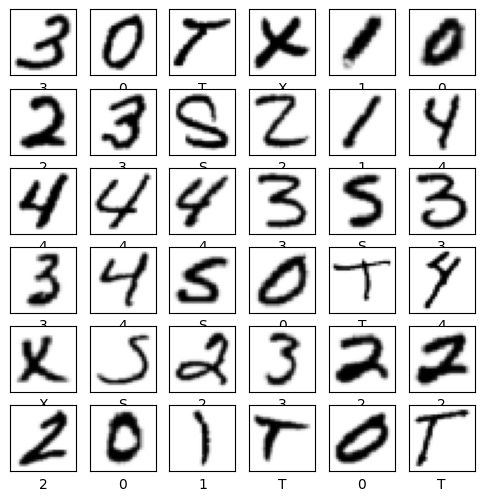

In [322]:
from matplotlib import pyplot as plt

#remapping labels to 0-7
label_mapping = {
    0:0, 1:1, 2:2, 3:3, 4:4, 
    28:5, 29:6, 33:7
}

alphabet_mapping = {
    0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: 'S', 6: 'T', 7: 'X' }

if np.any(np.isin(y_train, [28, 29, 33])):
    y_train = np.array([label_mapping[int(label)] for label in y_train])
    y_test  = np.array([label_mapping[int(label)] for label in y_test])

print(y_train)

N = x_train.shape[0]
idx = np.random.permutation(N)

plt.figure(figsize=(6,6))
for i, img in enumerate(x_train[36:72]):
    plt.subplot(6, 6, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(img.reshape(28,28), cmap=plt.cm.binary)
    plt.xlabel(alphabet_mapping[int(y_train[36 + i])])
plt.show()


Normaliziamo i dati per la rete neurale

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.00784314
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.02745098 0.1764706  0.24705882 0.00784314 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.01176471
 0.         0.         0.         0.         0.         0.
 0.         0.00784314 0.01568628 0.0352

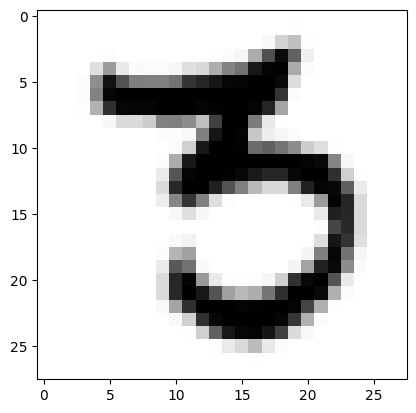

In [323]:
feature_vector_length = 28 * 28
x_train = x_train.reshape((x_train.shape[0], feature_vector_length)).astype('float32') / 255
x_test = x_test.reshape((x_test.shape[0], feature_vector_length)).astype('float32') / 255
print(x_test[1])
plt.imshow(x_test[1].reshape(28,28), cmap=plt.cm.binary)

### Il MLP completamente connesso è composto da: 1 layer di input, 2 layer nascosti e un layer di output finale. In totale abbiamo layer da 256, 128 e 8 neuroni (uno per ogni etichetta). Il layer di input e i layer nascosti utilizzano la funzione di attivazione "ReLU". Il modello riceve in input un vettore monodimensionale di dimensione 28×28 (il numero totale di pixel dell’immagine), che definisce la dimensione del layer di input. In questo caso, ReLU aiuta a contrastare il problema del vanishing gradient. Infine, utilizziamo softmax per ottenere la probabilità delle 8 classi.

In [324]:
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(feature_vector_length,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(8, activation='softmax')
])

model.summary()

/home/eraldi/IA/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,888 (917.53 KB)

 Trainable params: 234,888 (917.53 KB)

 Non-trainable params: 0 (0.00 B)

### Creazione di un arresto anticipato del modello nel caso in cui il modello stia andando in overfitting. Il parametro utilizzato è la loss del validation set.

In [325]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

### Ora addestriamo il modello utilizzando il training set ottenuto da EMNIST e quello personalizzato che abbiamo creato. Usiamo un massimo di 10 epoche e una batch size di 128. Per aggiornare i pesi dei neuroni utilizziamo l’ottimizzatore Adam, una versione ottimizzata dello stochastic gradient descent. Come funzione di loss utilizziamo la sparse categorical crossentropy, che calcola la perdita come $L(y,\hat{y}) = - \log({\hat{y}_{y}})$; questa funziona molto bene quando l’etichetta corretta può essere una sola e le etichette fornite sono interi

In [326]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# history = model.fit(combined_X_train, combined_y_train, epochs=10 ,batch_size=128, validation_split=0.1, callbacks=[early_stop])
history = model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.1, callbacks=[early_stop])


Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9103 - loss: 0.3271 - val_accuracy: 0.9542 - val_loss: 0.1348
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9698 - loss: 0.1089 - val_accuracy: 0.9672 - val_loss: 0.1084
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9807 - loss: 0.0695 - val_accuracy: 0.9677 - val_loss: 0.0872
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9858 - loss: 0.0483 - val_accuracy: 0.9760 - val_loss: 0.0715
Epoch 5/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9905 - loss: 0.0328 - val_accuracy: 0.9781 - val_loss: 0.0688
Epoch 6/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9940 - loss: 0.0222 - val_accuracy: 0.9750 - val_loss: 0.0744
Epoch 7/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9966 - loss: 0.0151 - val_accuracy: 0.9745 - val_loss: 0.0747
Epoch 8/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9981 - loss: 0.0090 - val_accuracy: 0.

100/100 - 0s - 2ms/step - accuracy: 0.9794 - loss: 0.0806

Test accuracy: 0.9793750047683716


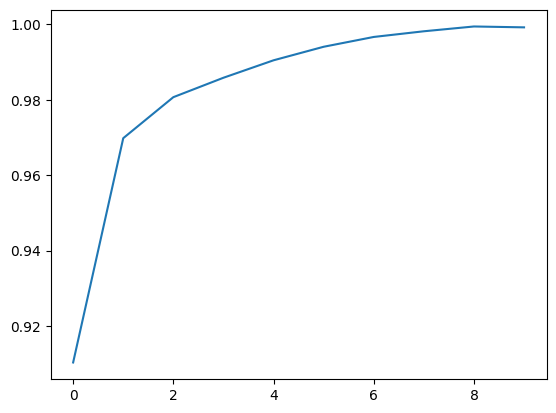

In [327]:
# mopdel evaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('\nTest accuracy:', test_acc)
# plotting training history
plt.plot(history.history['accuracy'], label='accuracy')

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


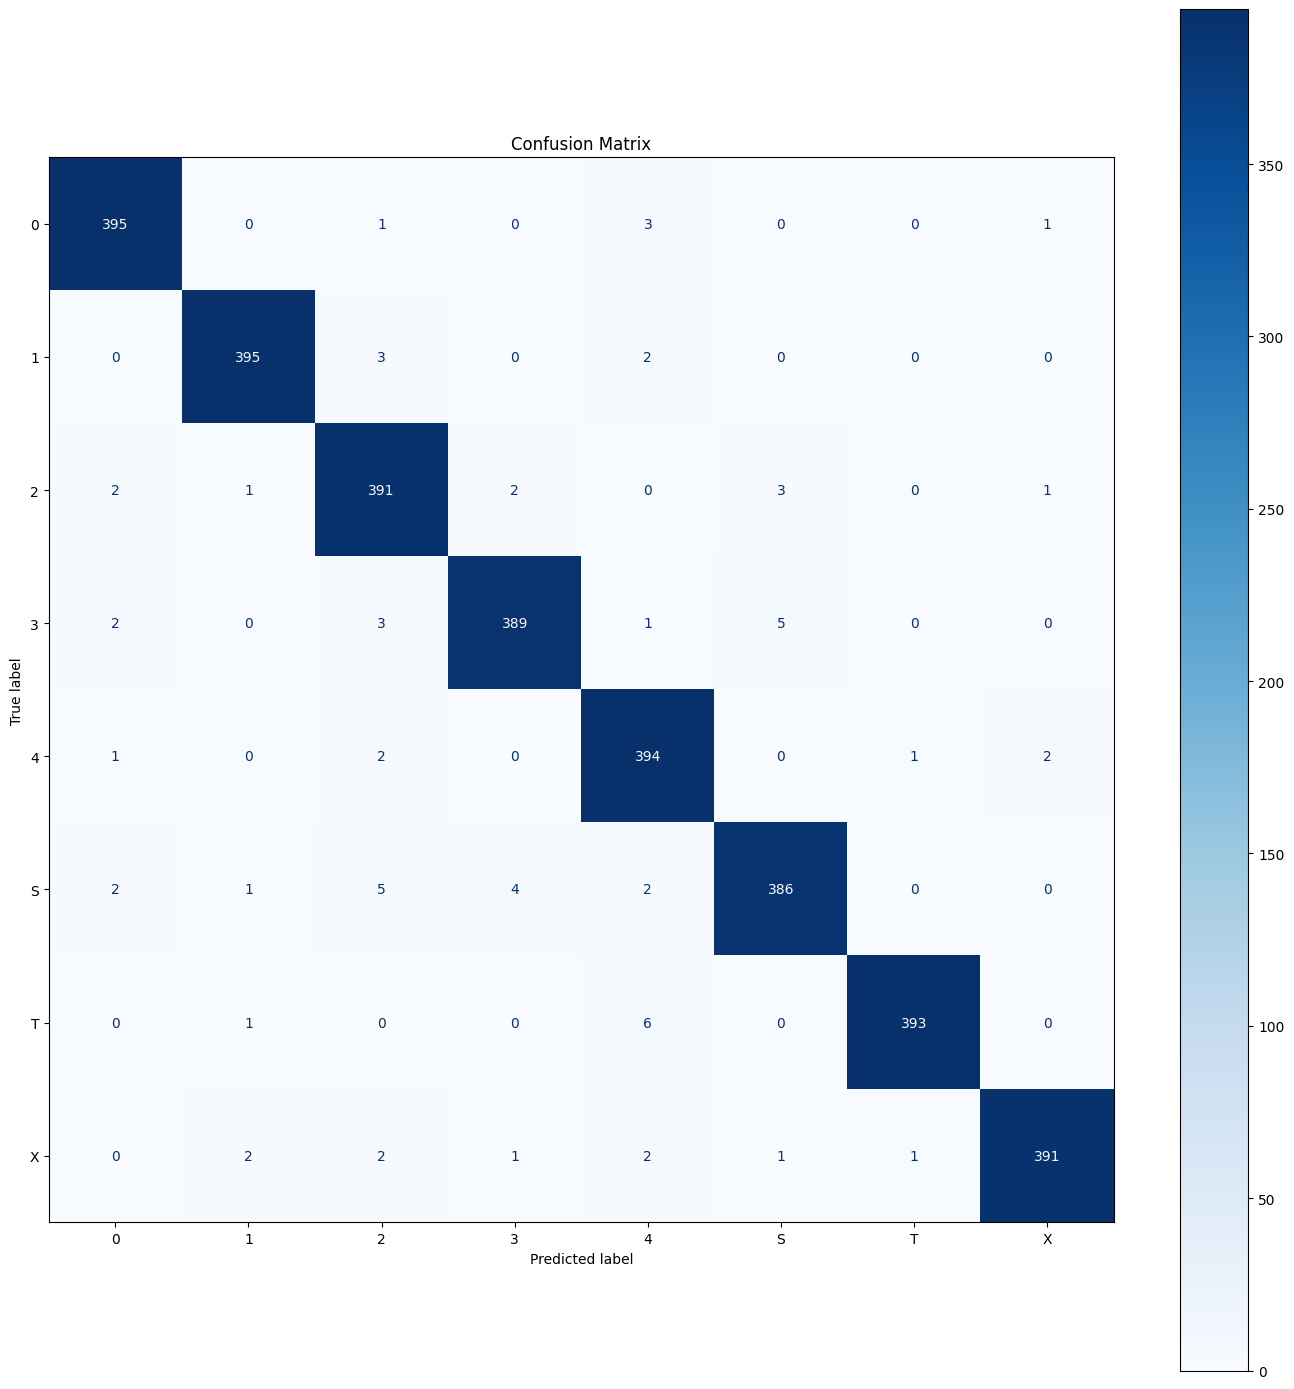

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       400
           1       0.99      0.99      0.99       400
           2       0.96      0.98      0.97       400
           3       0.98      0.97      0.98       400
           4       0.96      0.98      0.97       400
           S       0.98      0.96      0.97       400
           T       0.99      0.98      0.99       400
           X       0.99      0.98      0.98       400

    accuracy                           0.98      3200
   macro avg       0.98      0.98      0.98      3200
weighted avg       0.98      0.98      0.98      3200



In [328]:
# plotting the confusion matrix
from sklearn.metrics import confusion_matrix
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_classes)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(14, 14))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())
    plt.title('Confusion Matrix')
    plt.tight_layout() 
    plt.show()

plot_confusion_matrix(cm, labels=alphabet_mapping.values())
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes,
                            target_names=list(alphabet_mapping.values())))

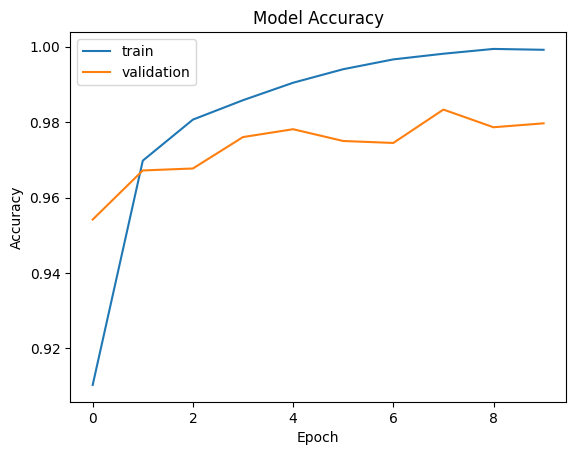

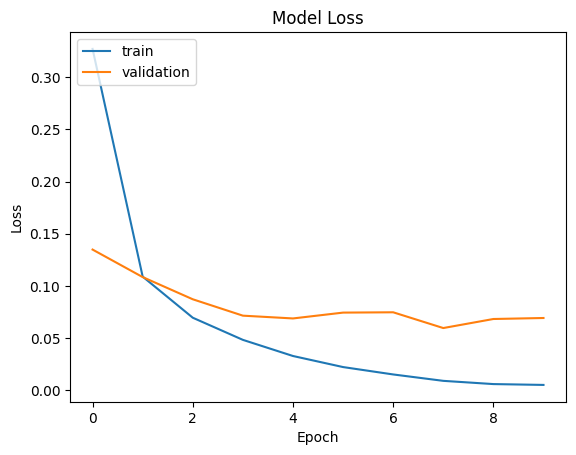

In [329]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [330]:
score = model.evaluate(x_test, y_test, verbose=False)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.08055342733860016
Test accuracy: 0.9793750047683716


## Ora usiamo la libreria OpenCV per estrarre le celle all'interno della griglia

### Il programma presenta la seguente pipeline:
- Leggiamo l'immagine e eseguiamo delle operazioni per pulirla (lettura in scala di grigi e aggiunta di un margine)
- Vengono estratte le linee verticali e orizzontali che formano l'immagine, trimite la funzione getBinaryMask.
    - Vengono fatte alcune operazioni morfologiche per individuare linee non continue ma che possono far parte della griglia.
- Vengono analizzati i contorni delle linee estratte per poter individuare le celle.
- Dalle celle estratte vengono prese solo quelle che non contengono a loro volta altri contorni, in modo tale da essere sicuri che siano le celle che stiamo cercando.

In [331]:
import cv2
import os
from pathlib import Path

In [332]:
def plotImage(image, title, saveToFile=False):
    """Mostra una singola immagine usando Matplotlib."""
    if len(image.shape) == 2:
        plt.imshow(image, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    if saveToFile:
        plt.savefig(f'{title}.png')
    plt.show()

In [333]:
def show_pipeline(images_with_titles, cols=4):
    n = len(images_with_titles)
    if n == 0: return
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    
    if n == 1: axes = [axes]
    elif rows == 1 or cols == 1: axes = axes.flatten()
    else: axes = axes.flatten()
    
    for i, ax in enumerate(axes):
        if i < n:
            img, title = images_with_titles[i]
            if len(img.shape) == 2:
                ax.imshow(img, cmap='gray')
            else:
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [334]:
def orderPoints(pts):
    """Ordina i vertici: Alto-Sx, Alto-Dx, Basso-Dx, Basso-Sx."""
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

In [ ]:
def sort_contours_2d(contours):
    """
    Ordina i contorni Top-Bottom e Left-Right, 
    restituendo una Matrice 2D (Lista di liste rappresentanti le righe).
    """
    boxes = [cv2.boundingRect(c) for c in contours]
    zipped = list(zip(contours, boxes))
    zipped.sort(key=lambda b: b[1][1])  # Prima per coordinata Y

    if not zipped: return []

    matrix = []
    current_row = []
    y_threshold = zipped[0][1][3] / 2  # Tolleranza mezza altezza cella

    for i in range(len(zipped)):
        current_cnt, current_box = zipped[i]
        
        if i == 0:
            current_row.append((current_cnt, current_box))
            continue
            
        _, prev_box = zipped[i-1]
        
        # Se la differenza Y è entro la tolleranza, è la stessa riga
        if abs(current_box[1] - prev_box[1]) < y_threshold:
            current_row.append((current_cnt, current_box))
        else:
            # Nuova riga: ordiniamo la vecchia per asse X e la salviamo nella matrice
            current_row.sort(key=lambda b: b[1][0])
            matrix.append([item[0] for item in current_row])
            
            # Iniziamo la nuova riga
            current_row = [(current_cnt, current_box)]
            y_threshold = current_box[3] / 2

    # Aggiungiamo l'ultima riga rimasta
    if current_row:
        current_row.sort(key=lambda b: b[1][0])
        matrix.append([item[0] for item in current_row])
            
    return matrix

In [336]:
def getBinaryMask(image):
    """Genera la maschera binaria robusta adatta sia a foto che render."""
    pipeline = []
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    pipeline.append((gray, "1. Grayscale"))
    
    # 1. Usato per tratti a penna blu/nera su foto (Canale Rosso)
    b, g, r = cv2.split(image)
    pipeline.append((r, "2. Canale Rosso"))
    
    # 2. Sfocatura dinamica (adattiva)
    h, w = gray.shape
    blur_ksize = int(min(h, w) * 0.006)
    if blur_ksize % 2 == 0: blur_ksize += 1
    blur_ksize = max(3, blur_ksize)
    
    blur = cv2.GaussianBlur(r, (blur_ksize, blur_ksize), 0)
    
    # 3. Adaptive Thresholding
    thresh = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY_INV, 35, 16)
    pipeline.append((thresh, "3. Adaptive Threshold"))
    
    # 4. Estrazione linee morfologiche
    # Kernel più corti (// 25) per non cancellare le linee a penna sbiadite
    kernel_len = max(5, min(w, h) // 25)
    
    # Spessore a 2 pixel per gestire i disallineamenti del disegno
    v_k = cv2.getStructuringElement(cv2.MORPH_RECT, (2, kernel_len))
    h_k = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_len, 2))
    
    # Estraiamo i frammenti di linea "superstiti"
    v_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, v_k)
    h_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, h_k)
    
    # Dilatiamo con forza le linee sul loro stesso asse per chiudere i buchi e ricucire le righe spezzate.
    # Un kernel (1, 15) stira i pixel verticali verso l'alto e verso il basso.
    v_stretch = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 25))
    h_stretch = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 1))
    
    v_lines = cv2.dilate(v_lines, v_stretch, iterations=1)
    h_lines = cv2.dilate(h_lines, h_stretch, iterations=1)
    
    # Uniamo le linee riparate
    grid_mask = cv2.add(v_lines, h_lines)
    pipeline.append((grid_mask, "4. Linee Base"))
    
    # 5. Chiusura globale e dilatazione incroci (per saldare le intersezioni X e Y)
    morph_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    grid_mask = cv2.dilate(grid_mask, morph_kernel, iterations=1)
    grid_mask = cv2.morphologyEx(grid_mask, cv2.MORPH_CLOSE, morph_kernel)
    
    # 6. Recinzione finta di sicurezza per le celle di bordo tagliate dalla foto
    cv2.rectangle(grid_mask, (0, 0), (w-1, h-1), 255, 6)
    pipeline.append((grid_mask, "5. Maschera Finale"))
    
    return grid_mask, pipeline

In [337]:
def extractCells(image_path, target_size=(100, 100), debug=True):
    """
    Estrae le celle ed effettua il Warp Perspective per raddrizzarle (come in findBoxes).
    Restituisce un array di celle appiattite.
    """
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Immagine {image_path} non trovata.")
        
    # Padding di sicurezza attorno all'immagine originale (20 pixel neri) per evitare fuoriuscite
    pad = 20
    padded_img = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=(0,0,0))
    
    # Ottengo la maschera
    binary_mask, pipeline = getBinaryMask(padded_img)
    
    # Trovo i contorni dei buchi neri (RETR_CCOMP per catturare l'interno della griglia)
    contours, hierarchy = cv2.findContours(binary_mask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    
    h, w = padded_img.shape[:2]
    total_area = h * w
    valid_contours = []
    
    debug_img = padded_img.copy()

    if contours and hierarchy is not None:
        for i, cnt in enumerate(contours):
            if hierarchy[0][i][3] != -1: # Se ha un genitore, è un buco interno
                area = cv2.contourArea(cnt)
                
                # Tolleranza Area: 0.1% - 40% dell'immagine
                if (total_area * 0.001) < area < (total_area * 0.4):
                    
                    # Usa approxPolyDP per ridurre i vertici
                    perimeter = cv2.arcLength(cnt, True)
                    approx = cv2.approxPolyDP(cnt, 0.04 * perimeter, True)
                    
                    x, y, w_c, h_c = cv2.boundingRect(cnt)
                    aspect_ratio = float(w_c) / h_c
                    
                    # Controllo aspect ratio (deve essere abbastanza quadrato/rettangolare)
                    if 0.2 < aspect_ratio < 4.0 and w_c > 15 and h_c > 15:
                        # Se l'approssimazione ha circa 4 vertici, usiamo l'approx, altrimenti passiamo il boundingRect
                        if len(approx) == 4 and cv2.isContourConvex(approx):
                            valid_contours.append(approx)
                        else:
                            # Fallback: creiamo un rettangolo finto partendo dal bounding box
                            rect_cnt = np.array([[[x, y]], [[x+w_c, y]], [[x+w_c, y+h_c]], [[x, y+h_c]]])
                            valid_contours.append(rect_cnt)

    if not valid_contours:
        print("Nessuna cella trovata!")
        return []

    # Pulizia contorni tramite dimensione mediana
    areas = [cv2.contourArea(c) for c in valid_contours]
    median_area = np.median(areas)
    
    final_contours = [c for c in valid_contours if median_area * 0.3 < cv2.contourArea(c) < median_area * 3.0]

    matrice_contorni = sort_contours_2d(final_contours) 
    
    
     # Calcolo Righe e Colonne
    righe = len(matrice_contorni)
    # Usiamo 'max' nel caso i disegni a mano abbiano una cella mancante in una riga
    colonne = max([len(riga) for riga in matrice_contorni]) if righe > 0 else 0 
    
    print(f"Dimensioni Griglia Rilevata: {righe} righe x {colonne} colonne")
    
    cropped_cells_2d = []
    flat_cropped_cells = [] # Tienilo per la pipeline di debug
    
    # Doppio ciclo for per mantenere la struttura a matrice delle immagini
    for row_contours in matrice_contorni:
        row_images = []
        for cnt in row_contours:
            cv2.drawContours(debug_img, [cnt], -1, (255, 0, 0), 3)
            
            pts = cnt.reshape(4, 2)
            rect = orderPoints(pts)
            
            dst_pts = np.array([
                [0, 0],
                [target_size[0]-1, 0],
                [target_size[0]-1, target_size[1]-1],
                [0, target_size[1]-1]
            ], dtype="float32")
            
            M = cv2.getPerspectiveTransform(rect, dst_pts)
            warped = cv2.warpPerspective(padded_img, M, target_size)
            
            margin = int(target_size[0] * 0.05)
            warped_clean = warped[margin:target_size[1]-margin, margin:target_size[0]-margin]
            
            row_images.append(warped_clean)
            flat_cropped_cells.append(warped_clean) # per il debug
            
        cropped_cells_2d.append(row_images)
        
    pipeline.append((debug_img, f"6. Celle Individuate ({righe}x{colonne})"))
    
    if debug:
        show_pipeline(pipeline, cols=3)
        
    # Ritorniamo la matrice, e i valori di righe e colonne
    return cropped_cells_2d, righe, colonne

## Dopo aver estratto le celle, facciamo delle operazioni per rendere le immagini quanto piu` simili a quelle di EMNIST

In [338]:
import glob
def zoom_and_preprocess(image):
    """
    Isola il carattere all'interno di una cella, rimuove i margini vuoti
    e lo formatta per modelli ML in scala di grigi 28x28 (es. EMNIST/MNIST).
    """
    # 1. Binarizzazione (Sfondo nero, tratto bianco)
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()
        
    # Usiamo Otsu per separare l'inchiostro dallo sfondo in modo netto
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # 2. Troviamo i contorni del tratto scritto
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Se la cella è vuota, ritorniamo un canvas 28x28 completamente nero
    if not contours:
        return np.zeros((28, 28), dtype=np.uint8)
        
    # Filtriamo il "rumore" (puntini neri o macchie sulla carta)
    min_area = 15 # Filtro area minima (modificabile se il tratto è molto sottile)
    valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]
    
    if not valid_contours:
        return np.zeros((28, 28), dtype=np.uint8)
        
    # 3. Calcolo del Bounding Box Globale 
    # (Calcoliamo la scatola che racchiude TUTTI i pezzi del carattere, ad es. i puntini sulle "i" o la "X")
    x_min, y_min = thresh.shape[1], thresh.shape[0]
    x_max, y_max = 0, 0
    
    for c in valid_contours:
        x, y, w, h = cv2.boundingRect(c)
        x_min = min(x_min, x)
        y_min = min(y_min, y)
        x_max = max(x_max, x + w)
        y_max = max(y_max, y + h)
        
    # Ritagliamo unicamente il carattere, buttando via tutto lo spazio laterale
    char_crop = thresh[y_min:y_max, x_min:x_max]
    
    h_crop, w_crop = char_crop.shape
    if h_crop == 0 or w_crop == 0:
        return np.zeros((28, 28), dtype=np.uint8)
        
    # 4. Formattazione Standard ML (Es: stile MNIST)
    # Scaliamo l'immagine in modo che il lato più lungo sia di 20 pixel (lasciando 4 pixel di margine per lato)
    max_dim = max(h_crop, w_crop)
    scale = 20.0 / max_dim
    
    new_w = int(w_crop * scale)
    new_h = int(h_crop * scale)
    
    # evito dimensioni a zero
    new_w = max(1, new_w)
    new_h = max(1, new_h)
    
    # Ridimensioniamo il carattere con interpolazione ad Area (ottima per rimpicciolire)
    resized_char = cv2.resize(char_crop, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # Dilatazione leggera opzionale (aiuta le reti neurali se il tratto di penna è diventato troppo fine)
    # kernel = np.ones((2,2), np.uint8)
    # resized_char = cv2.dilate(resized_char, kernel, iterations=1)
    
    # 5. Centratura su Tela 28x28
    canvas = np.zeros((28, 28), dtype=np.uint8)
    
    # Calcolo l'offset per posizionare il rettangolo ridimensionato perfettamente al centro
    x_off = (28 - new_w) // 2
    y_off = (28 - new_h) // 2
    
    canvas[y_off:y_off+new_h, x_off:x_off+new_w] = resized_char
    
    # IMPORTANTE: i modelli di Machine Learning standard si aspettano un input normalizzato.
    # Molti modelli EMNIST si aspettano che il carattere sia BIANCO su sfondo NERO 
    # (che è l'output attuale di questa funzione). 
    # Se il tuo modello si aspetta testo NERO su sfondo BIANCO, decommenta la riga sotto:
    # canvas = cv2.bitwise_not(canvas)
    
    return canvas

### Now we make the prediction of the extracted images with the model and we save the result in 2D list.

Dimensioni Griglia Rilevata: 4 righe x 6 colonne


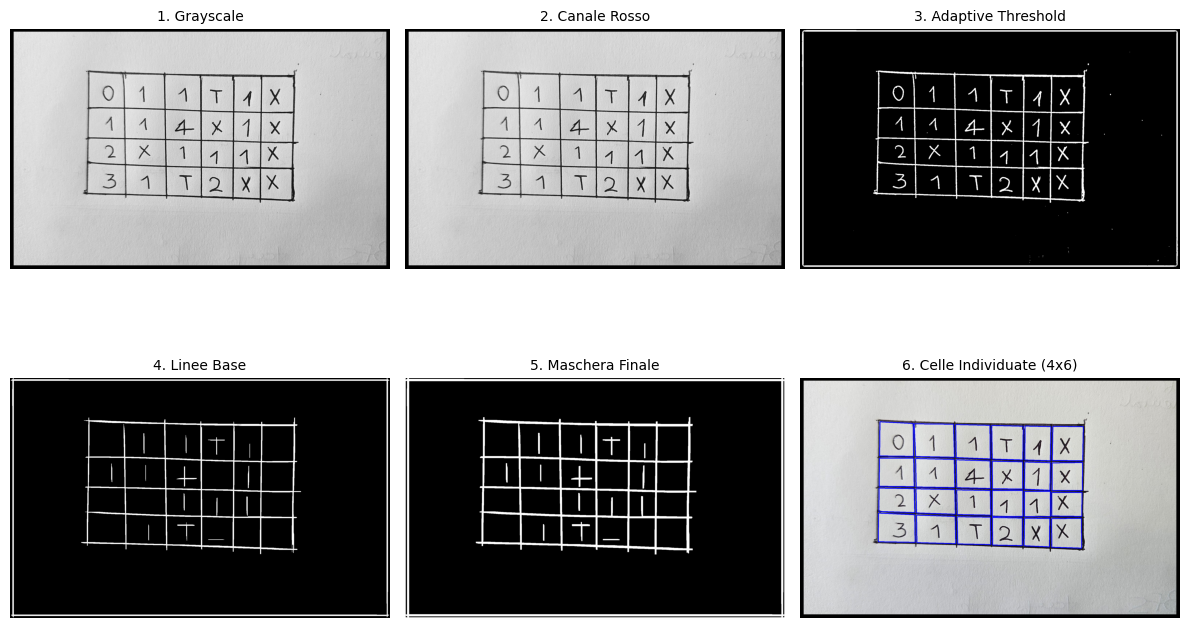

Script terminato. 24 celle estratte in una griglia 4x6.


In [355]:
img = 'griglia.jpeg'
try:
    celle_2d, righe, colonne = extractCells(img, target_size=(200, 200), debug=True)
    
    # Conta le celle effettive sommando la lunghezza di ogni riga
    num_celle_totali = sum(len(riga) for riga in celle_2d)
    print(f"Script terminato. {num_celle_totali} celle estratte in una griglia {righe}x{colonne}.")
    
    cv2.destroyAllWindows()
except Exception as e:
    print(f"Errore: {e}")


In [356]:
import numpy as np
import cv2

# Rimuoviamo folder, paths e glob perché le immagini sono già in memoria.

kernel = np.array([[0,1,0],
                   [0,1,0],
                   [0,0,0]], np.uint8)

X = []
imgs_show = []  
names = []

# celle_2d è una lista 2D: iteriamo sulle righe e poi sulle colonne
for i, row in enumerate(celle_2d):
    for j, cell in enumerate(row):
        
        img_zoomed = zoom_and_preprocess(cell)

        if img_zoomed.dtype != np.uint8:
            img_u8 = (img_zoomed * 255).astype('uint8')
        else:
            img_u8 = img_zoomed

        # Applichiamo la dilatazione
        img_thick = cv2.dilate(img_u8, kernel, iterations=1)

        # Normalizziamo
        img_norm = img_thick.astype('float32') / 255.0

        imgs_show.append(img_norm)           
        X.append(img_norm.flatten())
        
        # Assegniamo un nome fittizio usando gli indici della griglia
        names.append(f"cell_riga{i}_col{j}")

X = np.array(X, dtype='float32')         # (N, 784)
imgs_show = np.array(imgs_show)          # (N, 28, 28)

print("X shape:", X.shape)

X shape: (24, 784)


## Il modello effettua la predizione

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


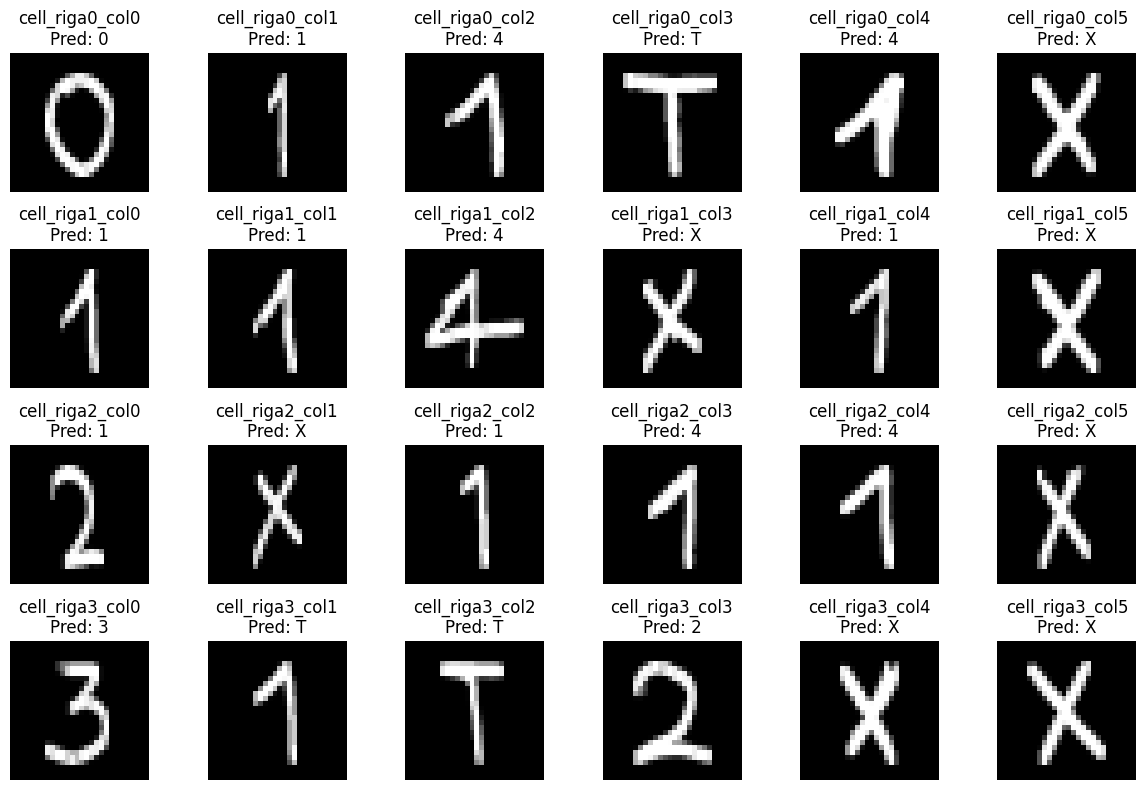

In [357]:
# predizione con il modello MLP EMNIST
probs = model.predict(X)
y_pred = np.argmax(probs, axis=1)

N = len(imgs_show)

# Calcoliamo il numero di righe e colonne reali della griglia
num_rows = len(celle_2d)
num_cols = len(celle_2d[0]) if num_rows > 0 else 0

# Ora num_rows e num_cols sono numeri interi validi
plt.figure(figsize=(2 * num_cols, 2 * num_rows))

for i in range(N):
    character = alphabet_mapping[y_pred[i]]
    
    # Creiamo il subplot usando le nuove variabili
    plt.subplot(num_rows, num_cols, i + 1)
    
    plt.imshow(imgs_show[i], cmap='gray')
    plt.title(f"{names[i]}\nPred: {character}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [358]:
# save the results in a numpy array
results = np.zeros((len(y_pred)))
for i in range(len(y_pred)):
    results[i] = y_pred[i]

print(results.shape)

(24,)


In [359]:
# convert the results in a list of characters
results_list = []
for i in range(len(y_pred)):
    results_list.append(alphabet_mapping[y_pred[i]])
print(results_list)

# convert the results in 2D list
results = []
for i in range(num_rows):
    rows = []
    for j in range(num_cols):
        idx = i * num_cols + j
        if idx < len(y_pred):
            rows.append(alphabet_mapping[y_pred[idx]])
        else:
            row.append('')
    results.append(rows)
print("Results in 2D list:")
print(results)

start = None
# find the start where the character is 'S'
for i in range(len(results)):
    for j in range(len(results[i])):
        if results[i][j] == 'S':
            start = (i, j)
            print("Start found at:", start)
if not start:
    print("Start character 'S' not found in the results.")
    start_input = input('Insert the start position as row,col (e.g., 0,0): ')
    start = tuple(map(int, start_input.split(',')))
    results[start[0]][start[1]] = 'S'

['0', '1', '4', 'T', '4', 'X', '1', '1', '4', 'X', '1', 'X', '1', 'X', '1', '4', '4', 'X', '3', 'T', 'T', '2', 'X', 'X']
Results in 2D list:
[['0', '1', '4', 'T', '4', 'X'], ['1', '1', '4', 'X', '1', 'X'], ['1', 'X', '1', '4', '4', 'X'], ['3', 'T', 'T', '2', 'X', 'X']]
Start character 'S' not found in the results.


# Research part

In [360]:
from aima.search import Problem, Node, memoize, PriorityQueue
from aima.search import depth_first_graph_search, breadth_first_graph_search, iterative_deepening_search, depth_limited_search
from collections.abc import Callable
import time

In [361]:
# Colori da usare nella print()
BLUE = "\033[34;1m"
RED = "\033[31;1m"
GREEN = "\033[32;1m"
RESET = "\033[0m"

In [362]:
from dataclasses import dataclass
from sre_parse import State
from typing import FrozenSet, Tuple

@dataclass(frozen=True)
class AgentState:
    col: int
    row: int
    treasures: FrozenSet[Tuple[int, int]]
    broken_walls: FrozenSet[Tuple[int, int]]

    def __repr__(self):
        return f"AgentState(col={self.col}, row={self.row}, treasures={self.treasures}, broken_walls={self.broken_walls})"
    

class GridTreasure(Problem): 
    def __init__(self, initial: AgentState, grid, required_treasures='max'):
        super().__init__(initial)
        self.grid = grid                                                      # Grid representation as a list of lists
        self.n = len(grid)                                                    # number of rows
        self.m = len(grid[0])                                                 # number of columns
        self.required_treasures = self.count_treasures(required_treasures)    # number of treasures in the grid
        self.treasure_to_collect = required_treasures                         # number of treasures to collect
        self.start_col, self.start_row = self.find_start()                    # find the starting position of 'S'

    # function to find the starting position 'S' in the grid
    def find_start(self):
        for r in range(self.n):
            for c in range(self.m):
                if self.grid[r][c] == 'S':
                    return c, r
        raise ValueError("Start position 'S' not found in the grid")

    # function return the number of treasures in the grid, if required is 'max' we count all the treasures, otherwise we return the minimum between the required and the number of treasures in the grid
    def count_treasures(self, required):
        if required == 'max':
            required = 0
            for r in range(self.n):
                for c in range(self.m):
                    if self.grid[r][c] == 'T':
                        required += 1
            return required
        else: 
            T = 0
            for r in range(self.n):
                for c in range(self.m):
                    if self.grid[r][c] == 'T':
                        T += 1
            if required > T:
                return T
            return required

    # goal is reached when the number of collected treasures equals the required number
    def goal_test(self, s: AgentState):
        return len(s.treasures) == self.required_treasures

    # function to count the number of treasures 'T' in the grid
    def treasure_number(self):
        treasures = 0
        for r in range(self.n):
            for c in range(self.m):
                if self.grid[r][c] == 'T':
                    treasures += 1
        return treasures
    
    def cell_cost(self, r, c, state):
        cell = self.grid[r][c]

        if cell in {'S', '0', 'T'}:
            return 0
        elif cell in {'1', '2', '3', '4'}:
            return int(cell)
        elif cell == 'X':
            return 1 if (r, c) in state.broken_walls else 5

        raise ValueError(f"Unknown cell type: {cell}")
    
    # possible actions are the valid moves (left, right, up, down)
    def actions(self, s: State):
        moves = []
        for name, dc, dr in [('left', -1, 0), ('right', 1, 0), ('up', 0, -1), ('down', 0, 1)]:  # direction vectors
            new_col = s.col + dc
            new_row = s.row + dr
            if 0 <= new_col < self.m and 0 <= new_row < self.n: # check bounds
                moves.append(name)
        return moves
    
    # result of an action is the new state after moving in the specified direction and collecting any treasure if present
    def result(self, s: State, move: str):
        dc, dr = {'left': (-1, 0), 'right': (1, 0), 'up': (0, -1), 'down': (0, 1)}[move]

        new_col = s.col + dc
        new_row = s.row + dr

        cell = self.grid[new_row][new_col]

        collected_treasures = set(s.treasures) # create a mutable copy of the collected treasures
        broken_walls = set(s.broken_walls)         # create a mutable copy of the broken walls

        if cell == 'T':
            collected_treasures.add((new_row, new_col))
        elif cell == 'X':   
            broken_walls.add((new_row, new_col))

        return AgentState(new_col, new_row, frozenset(collected_treasures), frozenset(broken_walls))
    
    # the cost of a path is the sum of the costs of the cells visited, including the cost of breaking walls and collecting treasures
    def path_cost(self, c, s1, a, s2):
        return c + self.cell_cost(s2.row, s2.col, s1) # cost of the new cell after the move

In [363]:

@dataclass
class Result:
    node: Node
    nodes_expanded: int
    explored_size: int
    frontier_size: int

def best_first_graph_search(problem: Problem, f: Callable) -> Result:
    f = memoize(f, 'f')
    node = Node(problem.initial)
    frontier = PriorityQueue('min', f)
    frontier.append(node)
    explored = set()
    counter = 1
    while frontier:
        node = frontier.pop()
        if problem.goal_test(node.state):
            return Result(node, counter, len(explored), len(frontier))
        explored.add(node.state)
        for child in node.expand(problem):
            counter += 1
            if child.state not in explored and child not in frontier:
                frontier.append(child)
            elif child in frontier:
                if f(child) < frontier[child]:
                    del frontier[child]
                    frontier.append(child)
    return Result(None, counter, len(explored), 0)

In [364]:
#astar search 
def astar_search(problem: Problem, h: Callable) -> Result:
    h = memoize(h, 'h')
    return best_first_graph_search(problem, lambda n: n.path_cost + h(n))

#manhattan distance heuristic
def manhattan_distance(state: AgentState, problem: GridTreasure):
    # heuristic is the manhattan distance to the nearest uncollected treasure
    min_dist = float('inf')
    for r in range(problem.n):
        for c in range(problem.m):
            if problem.grid[r][c] == 'T' and (r, c) not in state.treasures:
                dist = abs(state.row - r) + abs(state.col - c)
                min_dist = min(min_dist, dist)
    return min_dist if min_dist != float('inf') else 0

def cebysev_distance(state: AgentState, problem: GridTreasure):
    # heuristic is the chebyshev distance to the nearest uncollected treasure
    min_dist = float('inf')
    for r in range(problem.n):
        for c in range(problem.m):
            if problem.grid[r][c] == 'T' and (r, c) not in state.treasures:
                dist = max(abs(state.row - r), abs(state.col - c))
                min_dist = min(min_dist, dist)
    return min_dist if min_dist != float('inf') else 0

In [365]:
# Funzione per eseguire gli algoritmi e stampare alcune informazioni come
# risultato, costi della soluzione e tempo di esecuzione.
def execute(name: str, algorithm: Callable, problem: Problem, *args, **kwargs) -> None:
    print(f"{RED}{name}{RESET}\n")
    start = time.time()
    sol = algorithm(problem, *args, **kwargs)
    end = time.time()
    if problem.goal is not None:
        print(f"\n{GREEN}PROBLEM:{RESET} {problem.initial} -> {problem.goal}")
    if isinstance(sol, Result):
        print(f"{GREEN}Total nodes generated:{RESET} {sol.nodes_expanded}")
        print(f"{GREEN}Paths explored:{RESET} {sol.explored_size}")
        print(f"{GREEN}Nodes left in frontier:{RESET} {sol.frontier_size}")
        sol = sol.node 
    print(f"{GREEN}Result:{RESET} {sol.solution() if sol is not None else '---'}")
    if isinstance(sol, Node):
        print(f"{GREEN}Path Cost:{RESET} {sol.path_cost}")
        print(f"{GREEN}Path Length:{RESET} {sol.depth}")
    print(f"{GREEN}Time:{RESET} {end - start} s")

In [372]:
state = AgentState(start[1], start[0], frozenset(), frozenset())

Maze = GridTreasure(initial=state, grid=results, required_treasures='max')

execute("Uniform Cost Search", best_first_graph_search, Maze, lambda node: node.path_cost)


Uniform Cost Search

Total nodes generated: 349
Paths explored: 107
Nodes left in frontier: 58
Result: ['right', 'down', 'down', 'down', 'right', 'left', 'up', 'up', 'up', 'right', 'right']
Path Cost: 14
Path Length: 11
Time: 0.006545066833496094 s


In [373]:
execute("astar with manhattan", astar_search, Maze,  lambda node:manhattan_distance(node.state, Maze))

astar with manhattan

Total nodes generated: 328
Paths explored: 100
Nodes left in frontier: 50
Result: ['right', 'right', 'right', 'left', 'down', 'down', 'down', 'left']
Path Cost: 14
Path Length: 8
Time: 0.005096912384033203 s


In [374]:
# execute("Breadth-first Search", breadth_first_graph_search, Maze)

In [375]:
execute("A-star with Chebyshev heuristic", astar_search, Maze, lambda node:cebysev_distance(node.state, Maze))

A-star with Chebyshev heuristic

Total nodes generated: 324
Paths explored: 99
Nodes left in frontier: 49
Result: ['down', 'down', 'right', 'down', 'right', 'left', 'up', 'up', 'up', 'right', 'right']
Path Cost: 14
Path Length: 11
Time: 0.004620552062988281 s


In [376]:
execute("Depth-first Search", depth_first_graph_search, Maze)

Depth-first Search

Result: ['down', 'down', 'down', 'right', 'up', 'down', 'right', 'up', 'up', 'up', 'right']
Path Cost: 19
Path Length: 11
Time: 0.00021457672119140625 s
